In [3]:
# Import necessary libraries
import pandas as pd
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.datasets import load_iris
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. Load and Prepare Data
# ==========================================

In [4]:
# Load the Iris dataset
iris=load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [5]:
# Create a DataFrame from the Iris dataset
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [8]:
# Check and remove for duplicates 
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")

df.head()


Duplicate rows found: 0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


# ==========================================
# 2. Exploratory Data Analysis (EDA)
# ==========================================

In [15]:
# Display Dataset info
print("\n\n--- Dataset Info ---")
df.info()



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  149 non-null    float64
 1   sepal width (cm)   149 non-null    float64
 2   petal length (cm)  149 non-null    float64
 3   petal width (cm)   149 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [16]:
# Display statistical summary
print("\n\n--- Statistical Summary ---")
print(df.describe())

# Check for missing values
print("\n\n--- Missing values per column ---")
print(df.isnull().sum())



--- Statistical Summary ---
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         149.000000        149.000000         149.000000   
mean            5.843624          3.059732           3.748993   
std             0.830851          0.436342           1.767791   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.300000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        149.000000  
mean           1.194631  
std            0.762622  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


--- Missing values per column ---
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


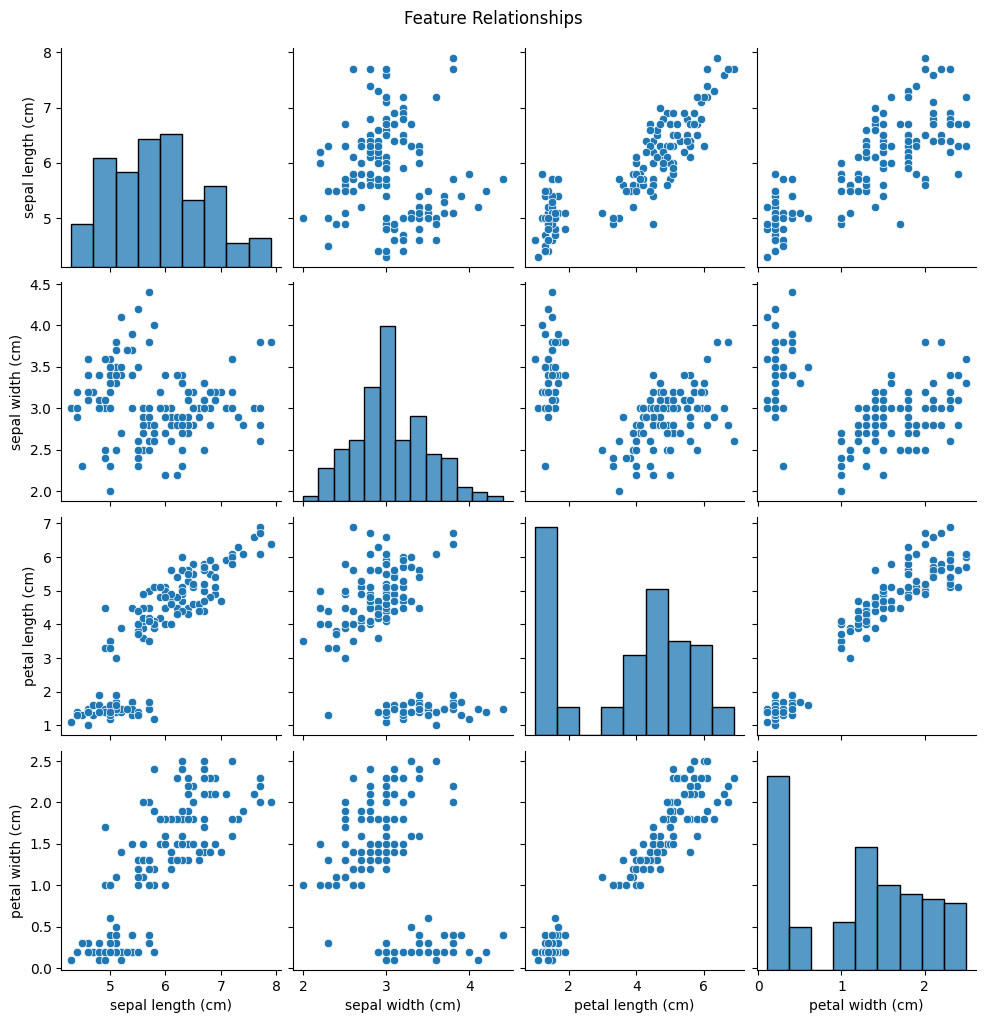

In [17]:
# Visualize relationships between all features
sns.pairplot(df)
plt.suptitle("Feature Relationships", y=1.02)
plt.show()

# ==========================================
# 3. Feature Selection & Scaling
# ==========================================

In [18]:
# Select two features for easy visualization
X = df[['petal length (cm)', 'petal width (cm)']]

# Scale data (K-Means uses distance, so scaling is important)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 4. Finding Optimal K (Elbow Method)
# ==========================================

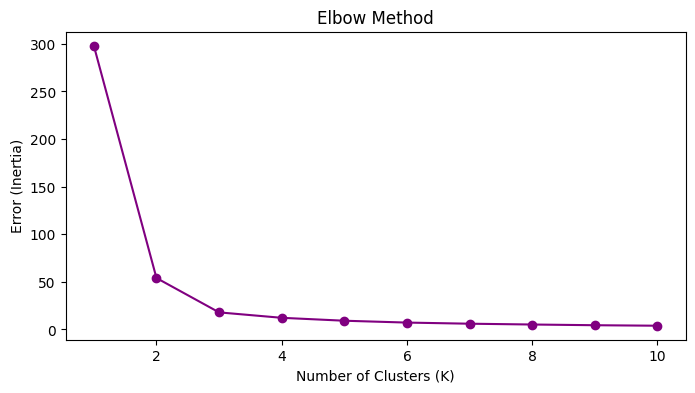

In [19]:
error = []

# Try different values of K (number of clusters)
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    
    # Store error (inertia)
    error.append(kmeans.inertia_)

# Plot elbow graph
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), error, marker='o', color='purple')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Error (Inertia)')

plt.show()

# ==========================================
# 5. Apply K-Means with Optimal K (K=3)
# ==========================================

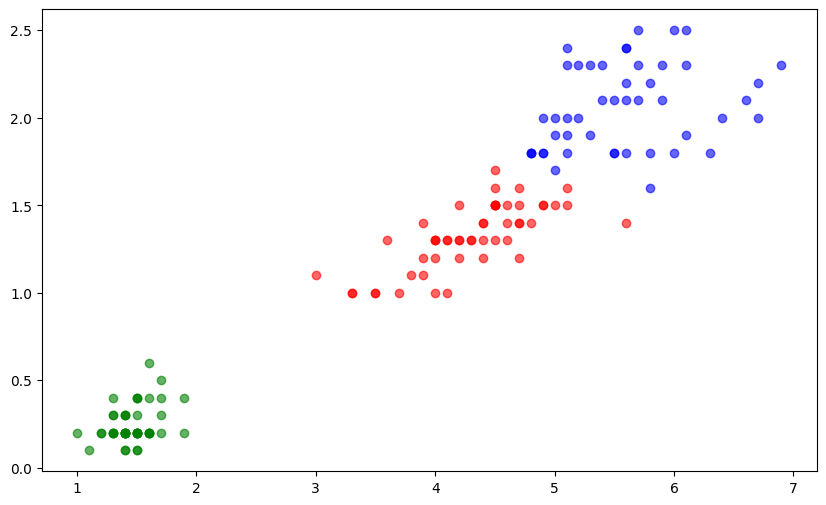

In [20]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
y_predict = kmeans.fit_predict(X_scaled)

# Visualization
plt.figure(figsize=(10, 6))

# Plotting Clusters
plt.scatter(X.iloc[y_predict == 0, 0], X.iloc[y_predict == 0, 1], c='red', label='Cluster 1', alpha=0.6)
plt.scatter(X.iloc[y_predict == 1, 0], X.iloc[y_predict == 1, 1], c='green', label='Cluster 2', alpha=0.6)
plt.scatter(X.iloc[y_predict == 2, 0], X.iloc[y_predict == 2, 1], c='blue', label='Cluster 3', alpha=0.6)


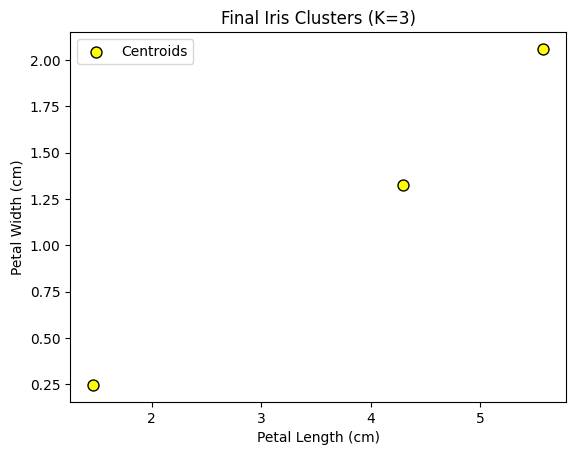

In [22]:
# Transform centroids back to original scale for plotting
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], s=250, c='yellow', marker='.', label='Centroids', edgecolors='black')

plt.title('Final Iris Clusters (K=3)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()
plt.show()


In [23]:
# Final Score
score = silhouette_score(X_scaled, y_predict)
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.6755
